In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import numpy as np
import matplotlib.pyplot as plt

import pickle
import json
import sys
sys.path.append("../../../")

from src.context_aware.config import ModelConfig, TrainingConfig, MetaConfig
from src.dataset_manager import DatasetConvertor 
from src.context_aware.preprocessing import PreprocessingDataset

In [2]:
rawDatasetFolder = "../../../data/raw"
dpdrDatasetFolder = "../../../data/processed/dpdr"
configPath = "../../config/combined_flows_forward_20.json"
modelFolder = "../../../data/models/context_aware"
verbose = True

In [3]:
datasetConverter = DatasetConvertor(rawDatasetFolder, randomFlag=False)
with open(configPath, "r") as f:
    config = json.load(f)

name = config.get("NAME")
len_window = config.get("LEN_WINDOW")
dim_data = len(config.get("CONTEXT_IDXS"))
train_ratio = config.get("TRAIN_RATIO")

datasetConverter.addDataUnit(config)
dataUnit = datasetConverter.getDataUnit(name)
max_vals, min_vals = dataUnit.getMaxMinMbnVals()
metaConfig = MetaConfig.initialize(
    dim_data=dim_data, 
    window_length=len_window, 
    max_vals=max_vals, 
    min_vals=min_vals
)
modelConfig = ModelConfig.from_meta_config(metaConfig)
trainDataUnit, testDataUnit = dataUnit.split(train_ratio)

# =============== Save ===============
testDataUnit.saveDataUnit(f"{dpdrDatasetFolder}/{name}.csv")
with open(f"{modelFolder}/{name}_modelConfig.pkl", "wb") as f:
    pickle.dump(modelConfig, f)
with open(f"{modelFolder}/{name}_metaConfig.pkl", "wb") as f:
    pickle.dump(metaConfig, f)

In [4]:
# =============== Preprocessing ===============
dataProcessor = PreprocessingDataset(metaConfig)
trainData = dataProcessor.process(trainDataUnit, dataAugment=False, filterMode='filtfilt')

In [5]:
import numpy as np



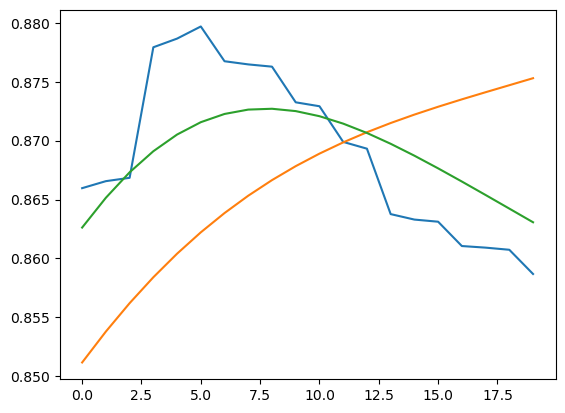

In [111]:
from src.context_aware.preprocessing.filter import KalmanFilter, smooth_timeseries_via_derivative

#kalman = KalmanFilter(dim_data, q_factor=1e-2, r_factor=1e-1)

src, _, _, _, _, _, _, src_raw = trainData

idx = np.random.randint(1, src_raw.shape[0])
input = np.concatenate([src_raw[idx-2, :, 0], src_raw[idx-1, :, 0], src_raw[idx, :, 0]], axis=0)
output, _ = smooth_timeseries_via_derivative(input, dt=0.01, lam=0.1)
# output is 1D, so just take the last N values, not multi-index
src_filtered = output[-len(src_raw[idx,:,0]):]


plt.plot(src_raw[idx,:,0])
plt.plot(src[idx,:,0])
plt.plot(src_filtered[:,])
plt.show()